# Prep

Load data

In [82]:
import pandas as pd

# Load dataset
df = pd.read_csv("MJMusicDataset.csv")

# Quick check
print(df.shape)
print(df.head())


(926, 72)
                              name dastgah instrument  zero_corssing  \
0         ney-mahoor-ebrahimi .mp3     D_2        I_4          65545   
1  Mohammad_Shojaei_nei_Mahoor.mp3     D_2        I_4          59788   
2      Arash_Samimi_nei_Mahoor.mp3     D_2        I_4          85072   
3          19 sarebaang mahoor.mp3     D_2        I_4          89980   
4                     Amjadian.mp3     D_2        I_4          58134   

   spectral_centroid_mean  spectral_centroid_var  spectral_rolloff_mean  \
0             1938.040517            303472.4474            2815.166310   
1             1956.981873            774951.2677            2971.032035   
2             2735.525193            575671.7929            4268.615855   
3             2629.389833            406198.9319            4071.233715   
4             1659.262559            332341.1003            2789.041468   

   spectral_rolloff_var  chroma_1_mean  chroma_2_mean  ...  mfcc_11_var  \
0          1.754412e+06       0

Summery of data

In [3]:
# Abstract summary of dataset
summary = {
    "shape": df.shape,
    "columns": list(df.columns),
    "dtypes": df.dtypes.value_counts().to_dict(),
    "missing_total": int(df.isnull().sum().sum()),
    "missing_by_col": df.isnull().sum()[df.isnull().sum() > 0].to_dict(),
    "numeric_cols": df.select_dtypes(include='number').shape[1],
    "categorical_cols": df.select_dtypes(exclude='number').shape[1],
    "sample": df.sample(3).to_dict(orient="records")
}

import pprint
pprint.pprint(summary, width=120)


{'categorical_cols': 3,
 'columns': ['name',
             'dastgah',
             'instrument',
             'zero_corssing',
             'spectral_centroid_mean',
             'spectral_centroid_var',
             'spectral_rolloff_mean',
             'spectral_rolloff_var',
             'chroma_1_mean',
             'chroma_2_mean',
             'chroma_3_mean',
             'chroma_4_mean',
             'chroma_5_mean',
             'chroma_6_mean',
             'chroma_7_mean',
             'chroma_8_mean',
             'chroma_9_mean',
             'chroma_10_mean',
             'chroma_11_mean',
             'chroma_12_mean',
             'chroma_1_var',
             'chroma_2_var',
             'chroma_3_var',
             'chroma_4_var',
             'chroma_5_var',
             'chroma_6_var',
             'chroma_7_var',
             'chroma_8_var',
             'chroma_9_var',
             'chroma_10_var',
             'chroma_11_var',
             'chroma_12_var',
        

In [4]:
df.head()

,name,dastgah,instrument,zero_corssing,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,chroma_1_mean,chroma_2_mean,...,mfcc_11_var,mfcc_12_var,mfcc_13_var,mfcc_14_var,mfcc_15_var,mfcc_16_var,mfcc_17_var,mfcc_18_var,mfcc_19_var,mfcc_20_var
0,ney-mahoor-ebrahimi .mp3,D_2,I_4,65545,1938.040517,303472.4474,2815.166310,1.754412e+06,0.515210,0.158007,...,482.619965,274.530334,257.260315,200.793167,177.008484,89.304535,49.159683,83.412254,154.657501,417.060425
1,Mohammad_Shojaei_nei_Mahoor.mp3,D_2,I_4,59788,1956.981873,774951.2677,2971.032035,2.082504e+06,0.209722,0.335278,...,435.338196,289.941559,337.219269,266.507416,256.131317,153.390289,90.073257,120.354729,206.031006,267.015015
2,Arash_Samimi_nei_Mahoor.mp3,D_2,I_4,85072,2735.525193,575671.7929,4268.615855,2.663909e+06,0.105867,0.108526,...,299.526794,226.705948,163.451355,140.664673,104.658630,72.048088,53.397228,83.085548,190.668487,331.626526
3,19 sarebaang mahoor.mp3,D_2,I_4,89980,2629.389833,406198.9319,4071.233715,1.005496e+06,0.153988,0.098157,...,305.978638,154.510696,281.793976,348.872650,156.062454,85.470512,45.904568,120.363800,370.077820,306.180878
4,Amjadian.mp3,D_2,I_4,58134,1659.262559,332341.1003,2789.041468,8.496746e+05,0.077795,0.036009,...,81.764854,106.146141,103.081779,85.252548,90.831291,150.201111,332.417633,299.858795,177.197845,186.112488


# Analysis

distribution of Dastgah

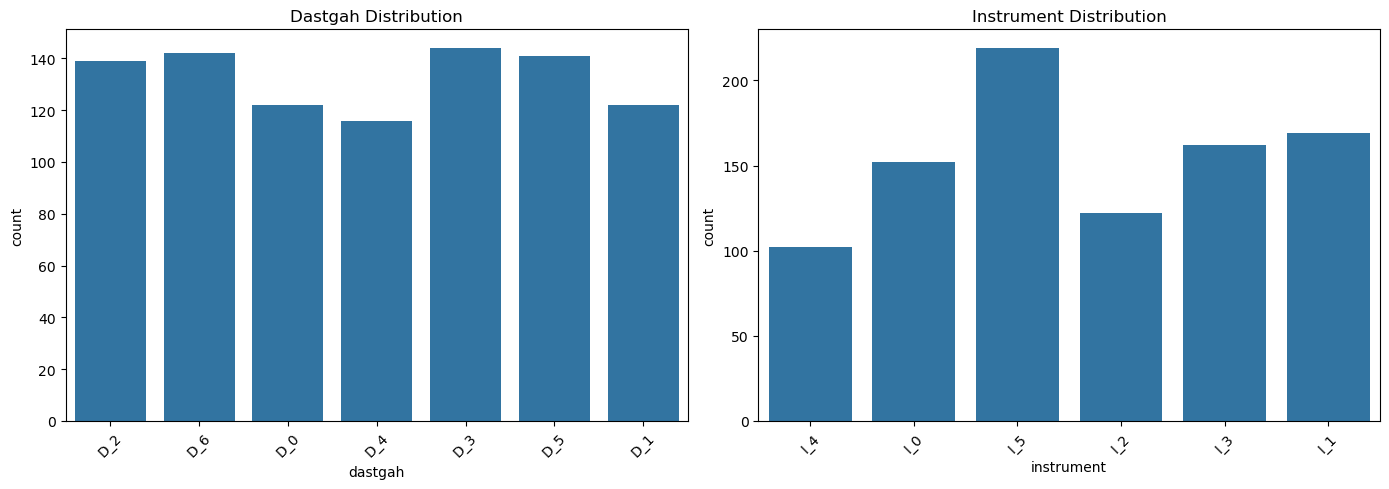

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- categorical balance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="dastgah", data=df, ax=axes[0])
axes[0].set_title("Dastgah Distribution")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x="instrument", data=df, ax=axes[1])
axes[1].set_title("Instrument Distribution")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



Train test split

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features
X = df.drop(columns=["name", "instrument", "dastgah"])

# Labels as numbers
le = LabelEncoder()
y = le.fit_transform(df["dastgah"])   # e.g. D_0 → 0, D_1 → 1, ...

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Classes:", le.classes_)


(740, 69) (186, 69) (740,) (186,)
Classes: ['D_0' 'D_1' 'D_2' 'D_3' 'D_4' 'D_5' 'D_6']


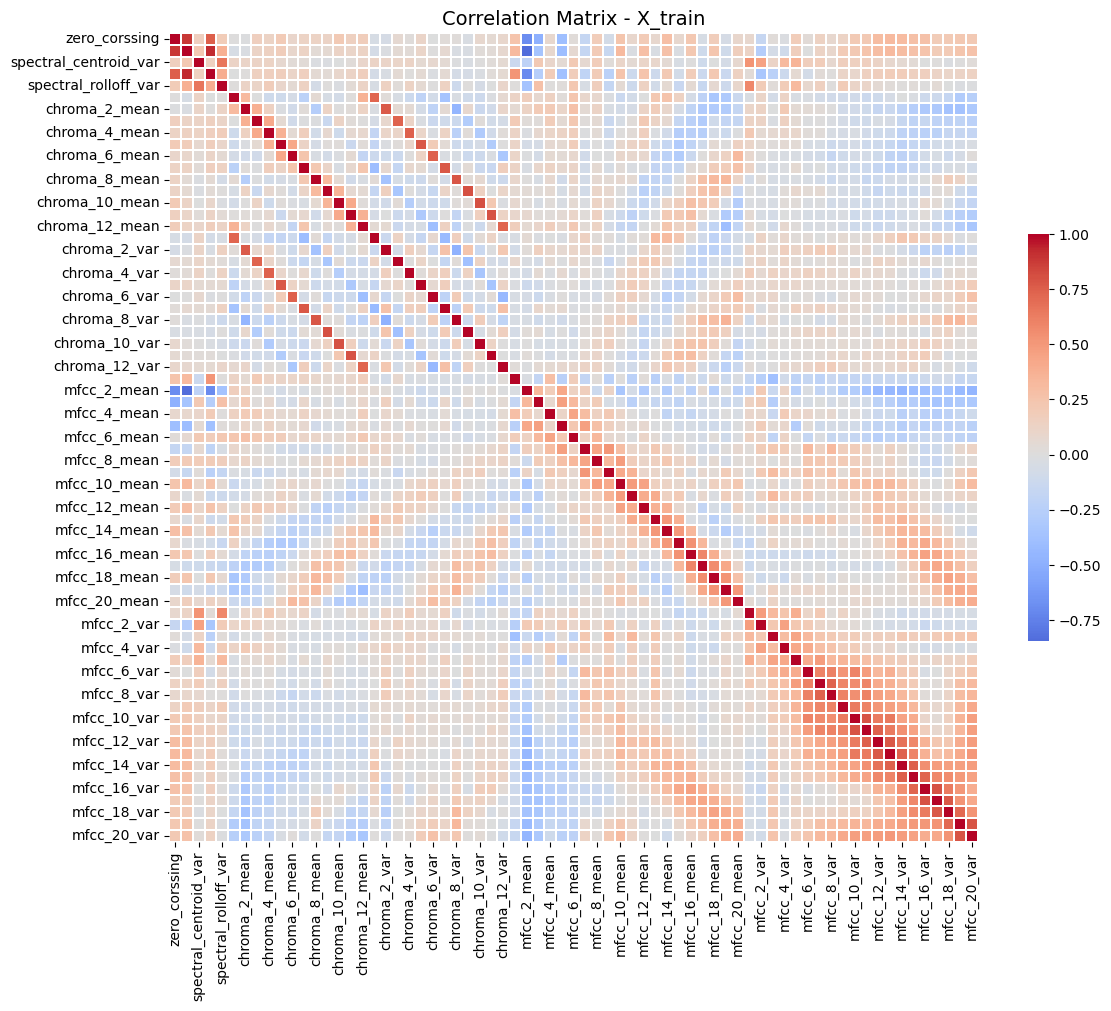

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Correlation matrix ---
plt.figure(figsize=(12, 10))
corr = X_train.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.5},
    linewidths=0.1
)

plt.title("Correlation Matrix - X_train", fontsize=14)
plt.tight_layout()
plt.show()


In [14]:
X.columns

Index(['zero_corssing', 'spectral_centroid_mean', 'spectral_centroid_var',
       'spectral_rolloff_mean', 'spectral_rolloff_var', 'chroma_1_mean',
       'chroma_2_mean', 'chroma_3_mean', 'chroma_4_mean', 'chroma_5_mean',
       'chroma_6_mean', 'chroma_7_mean', 'chroma_8_mean', 'chroma_9_mean',
       'chroma_10_mean', 'chroma_11_mean', 'chroma_12_mean', 'chroma_1_var',
       'chroma_2_var', 'chroma_3_var', 'chroma_4_var', 'chroma_5_var',
       'chroma_6_var', 'chroma_7_var', 'chroma_8_var', 'chroma_9_var',
       'chroma_10_var', 'chroma_11_var', 'chroma_12_var', 'mfcc_1_mean',
       'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean',
       'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean',
       'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean',
       'mfcc_14_mean', 'mfcc_15_mean', 'mfcc_16_mean', 'mfcc_17_mean',
       'mfcc_18_mean', 'mfcc_19_mean', 'mfcc_20_mean', 'mfcc_1_var',
       'mfcc_2_var', 'mfcc_3_var', 'mfcc_4_var', 'mfcc_5_var', 'm

distribution after train test split

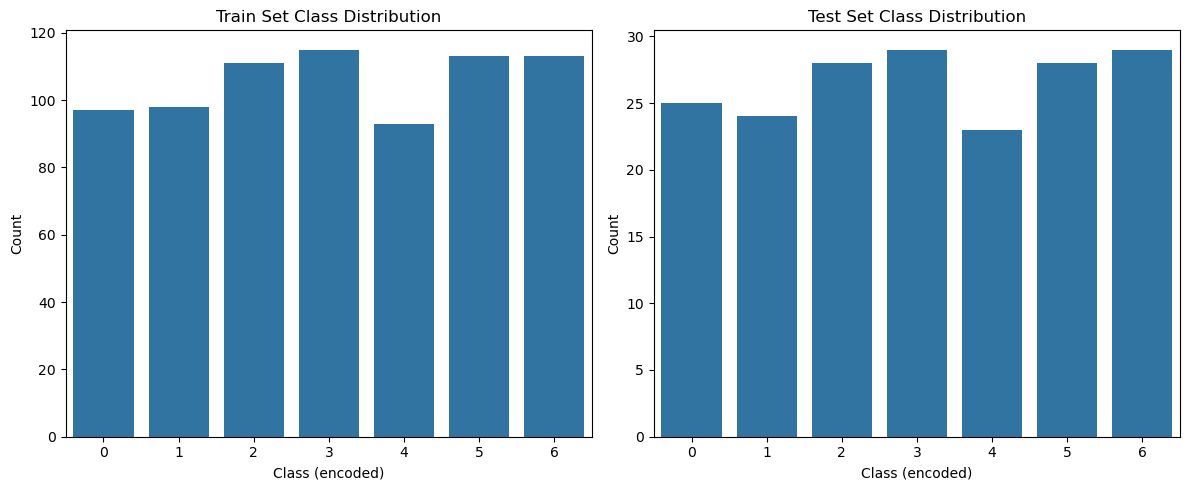

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Bar plots: class balance in train/test ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Train Set Class Distribution")
axes[0].set_xlabel("Class (encoded)")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Class (encoded)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()



normalization

In [26]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (740, 69)  Test shape: (186, 69)


In [30]:
from imblearn.over_sampling import RandomOverSampler

# Oversample train set only
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

print("Before:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After :", dict(zip(*np.unique(y_train_bal, return_counts=True))))


Before: {0: 97, 1: 98, 2: 111, 3: 115, 4: 93, 5: 113, 6: 113}
After : {0: 115, 1: 115, 2: 115, 3: 115, 4: 115, 5: 115, 6: 115}


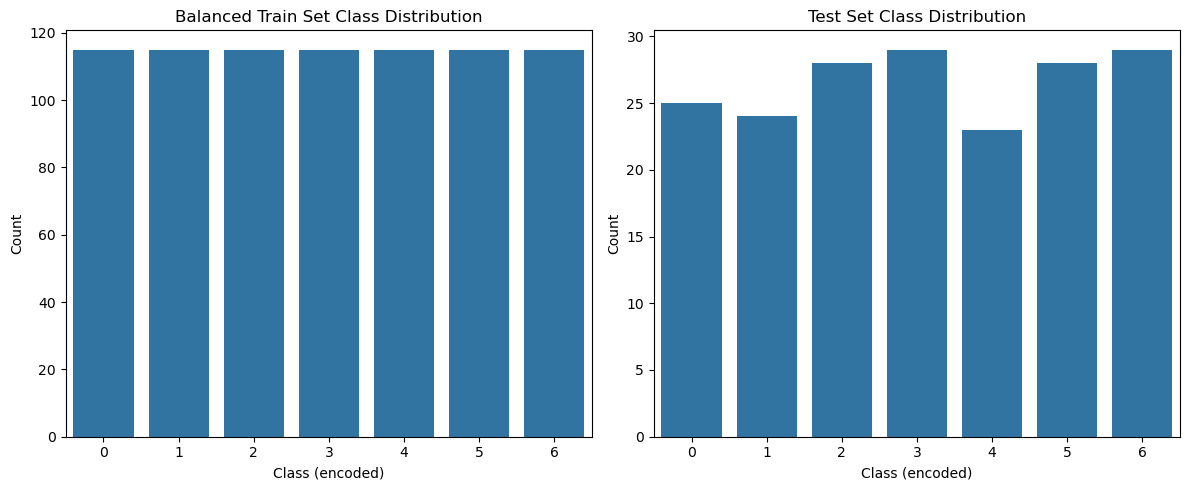

In [32]:
from imblearn.over_sampling import RandomOverSampler

# Oversample train set
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train_scaled, y_train)

# --- Bar plots: balanced vs test ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train_bal, ax=axes[0])
axes[0].set_title("Balanced Train Set Class Distribution")
axes[0].set_xlabel("Class (encoded)")
axes[0].set_ylabel("Count")

sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xlabel("Class (encoded)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17043
[LightGBM] [Info] Number of data points in the train set: 740, number of used features: 69
[LightGBM] [Info] Start training from score -2.031939
[LightGBM] [Info] Start training from score -2.021683
[LightGBM] [Info] Start training from score -1.897120
[LightGBM] [Info] Start training from score -1.861718
[LightGBM] [Info] Start training from score -2.074051
[LightGBM] [Info] Start training from score -1.879262
[LightGBM] [Info] Start training from score -1.879262
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

/home/alireza-linux/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


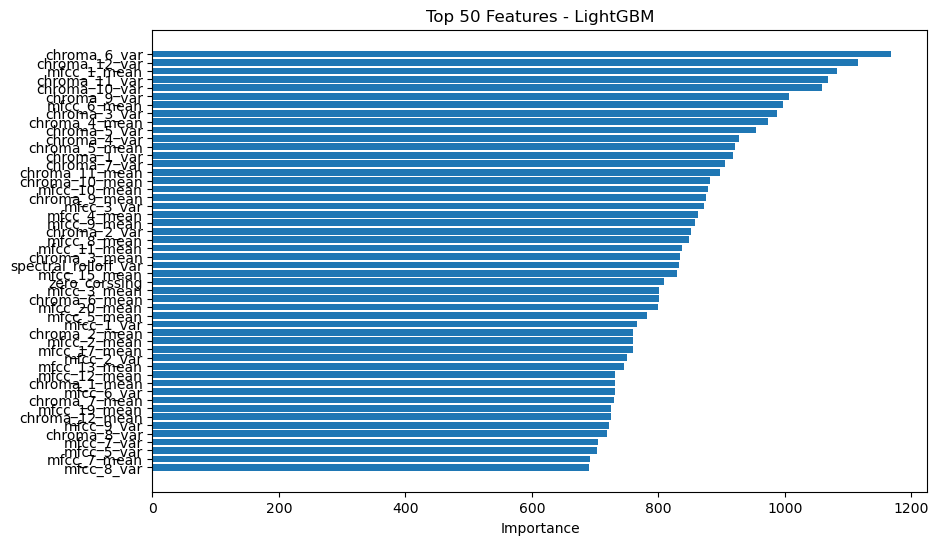

In [34]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- Train LightGBM ---
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm.fit(X_train_scaled, y_train)

# --- Predictions ---
y_pred = lgbm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Feature importance ---
importances = lgbm.feature_importances_
sorted_idx = importances.argsort()[::-1][:50]  # top 20 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), importances[sorted_idx][::-1])
plt.yticks(range(len(sorted_idx)), [X.columns[i] for i in sorted_idx][::-1])
plt.xlabel("Importance")
plt.title("Top 50 Features - LightGBM")
plt.show()


In [54]:
# --- Select top k features ---
k = 50  # change to 20 if you want leaner

# Get top-k feature indices from LightGBM importances
importances = lgbm.feature_importances_
sorted_idx = importances.argsort()[::-1][:k]
top_features = [X.columns[i] for i in sorted_idx]

print("Top features:", top_features)

# Filter both train and test
X_train_top = X_train_scaled[:, sorted_idx]
X_test_top = X_test_scaled[:, sorted_idx]

print("Train shape:", X_train_top.shape, " Test shape:", X_test_top.shape)


Top features: ['chroma_6_var', 'chroma_12_var', 'mfcc_1_mean', 'chroma_11_var', 'chroma_10_var', 'chroma_9_var', 'mfcc_6_mean', 'chroma_3_var', 'chroma_4_mean', 'chroma_5_var', 'chroma_4_var', 'chroma_5_mean', 'chroma_1_var', 'chroma_7_var', 'chroma_11_mean', 'chroma_10_mean', 'mfcc_10_mean', 'chroma_9_mean', 'mfcc_3_var', 'mfcc_4_mean', 'mfcc_9_mean', 'chroma_2_var', 'mfcc_8_mean', 'mfcc_11_mean', 'chroma_3_mean', 'spectral_rolloff_var', 'mfcc_15_mean', 'zero_corssing', 'mfcc_3_mean', 'chroma_6_mean', 'mfcc_20_mean', 'mfcc_5_mean', 'mfcc_1_var', 'chroma_2_mean', 'mfcc_2_mean', 'mfcc_17_mean', 'mfcc_2_var', 'mfcc_13_mean', 'mfcc_12_mean', 'chroma_1_mean', 'mfcc_6_var', 'chroma_7_mean', 'mfcc_19_mean', 'chroma_12_mean', 'mfcc_9_var', 'chroma_8_var', 'mfcc_7_var', 'mfcc_5_var', 'mfcc_7_mean', 'mfcc_8_var']
Train shape: (740, 50)  Test shape: (186, 50)


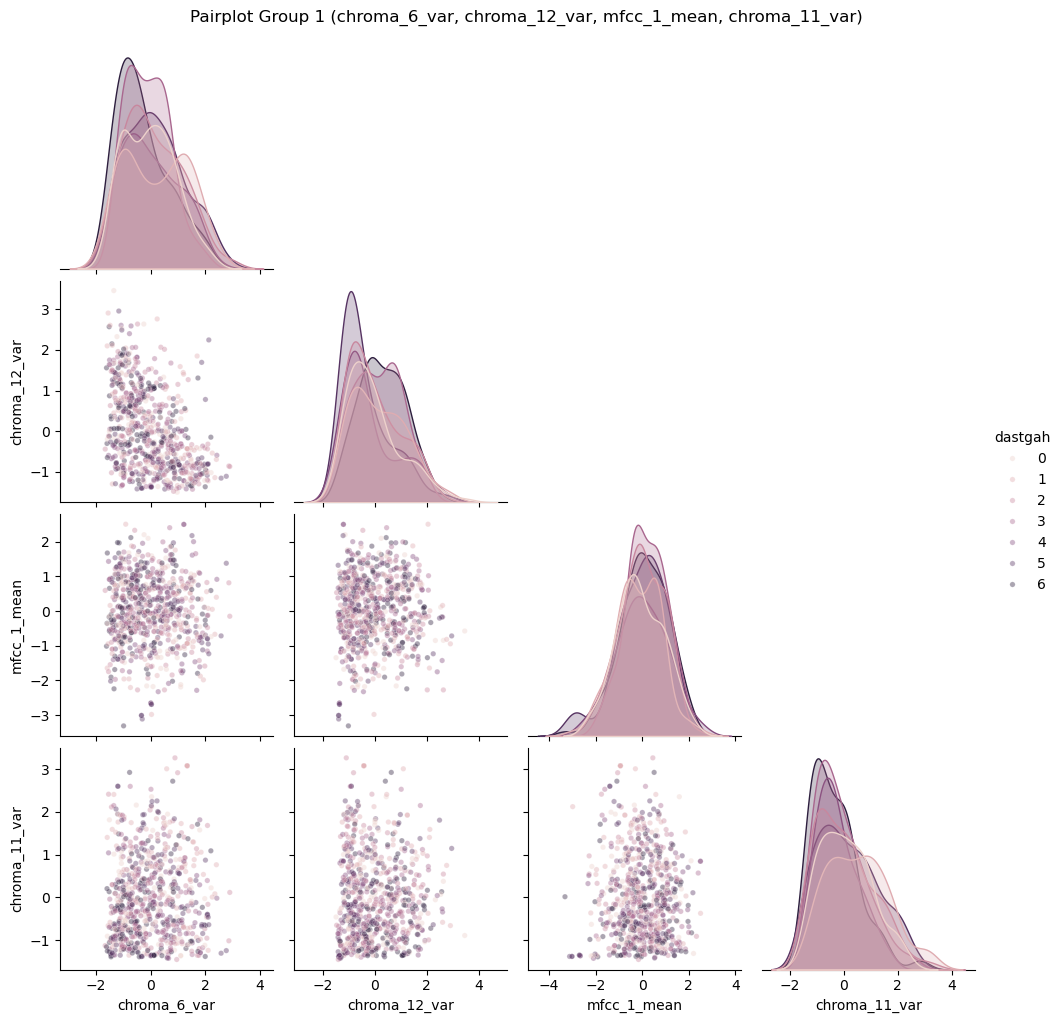

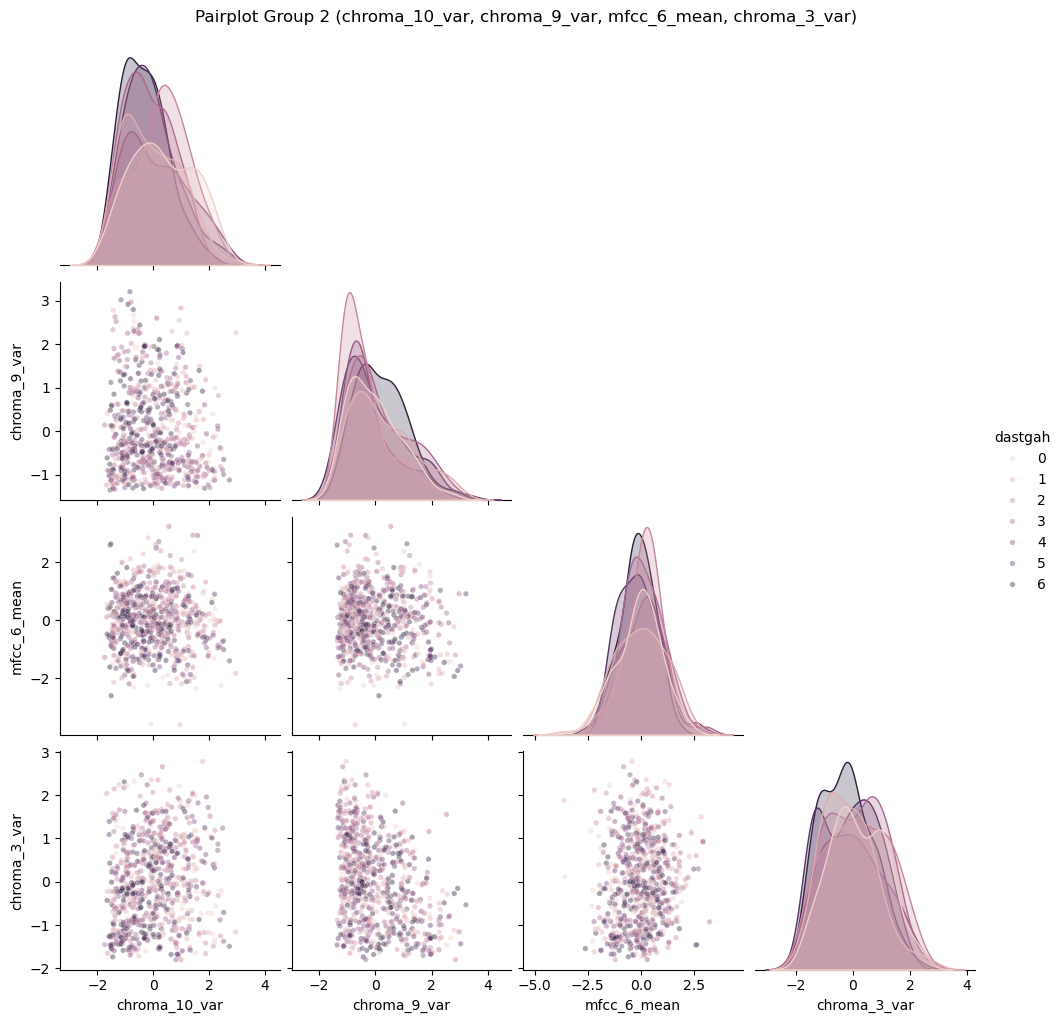

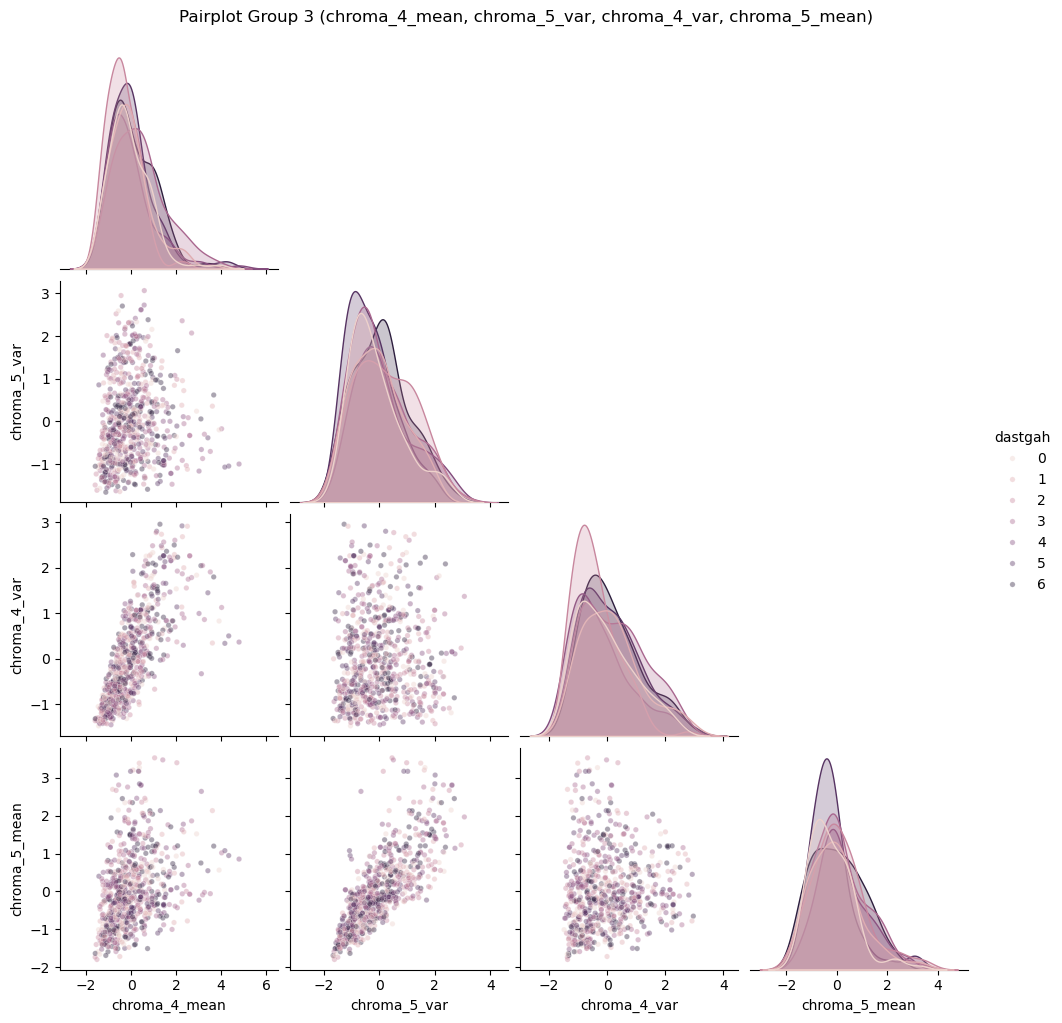

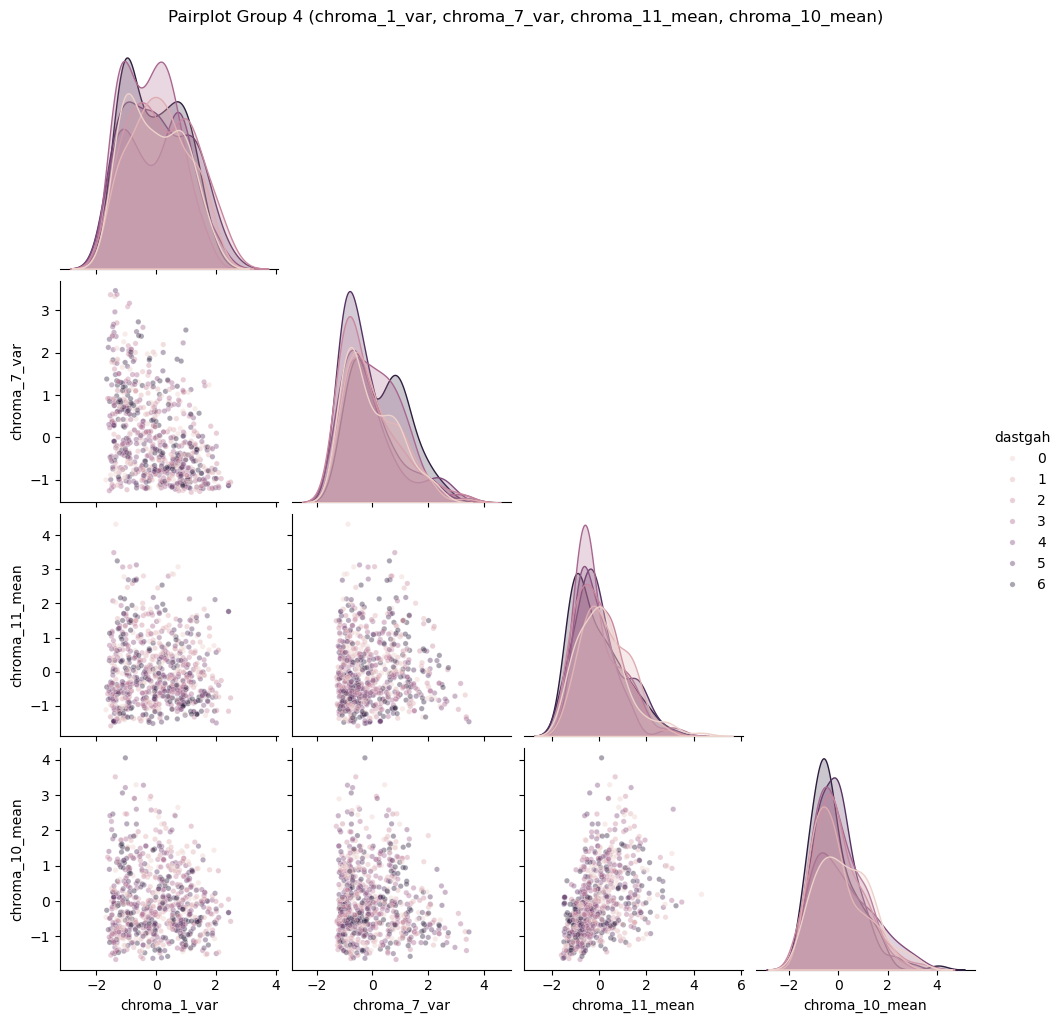

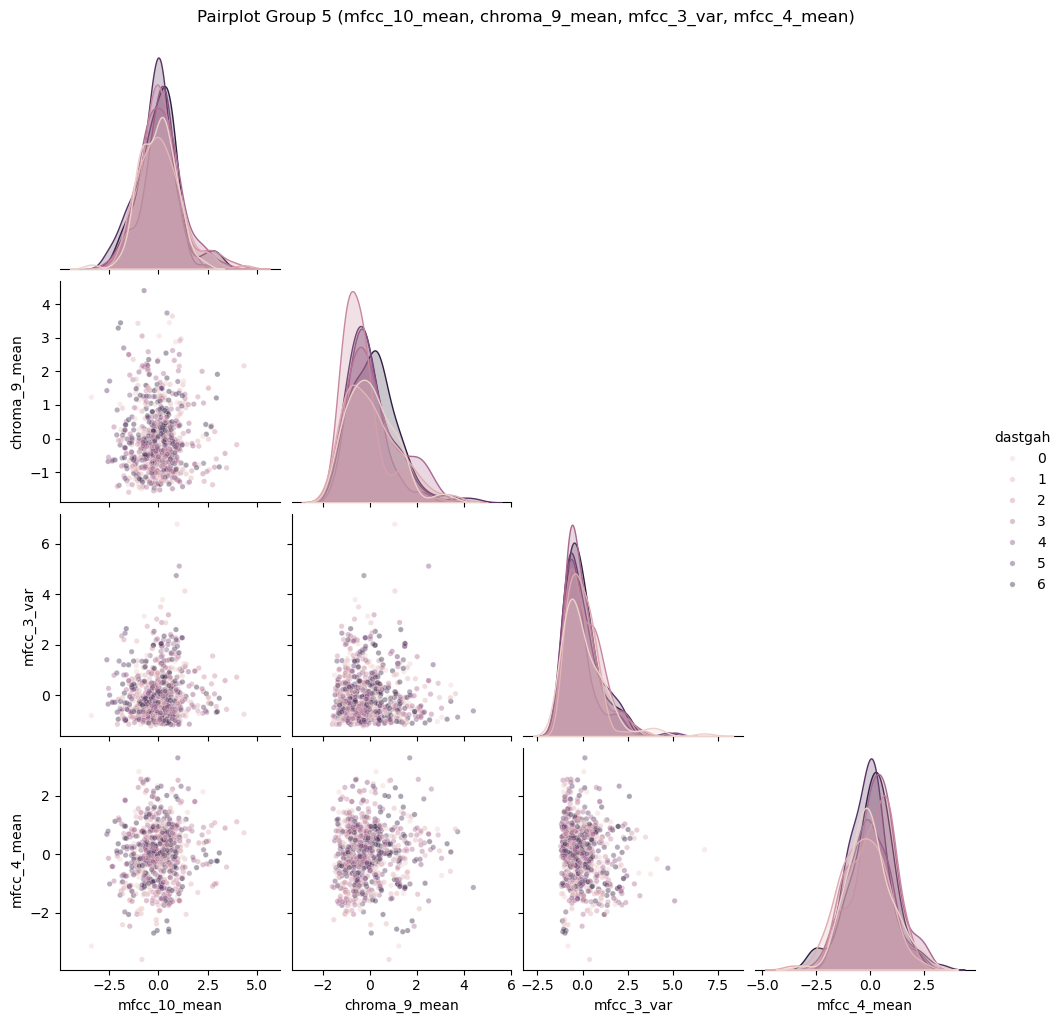

In [70]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Top 20 features
k = 20
sorted_idx = importances.argsort()[::-1][:k]
top50_features = [X.columns[i] for i in sorted_idx]

# Rebuild scaled DataFrame for train set
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_top50 = X_train_df[top50_features].copy()
X_train_top50["dastgah"] = y_train  # labels for coloring

# Split into 5 groups of 4 features
groups = [top50_features[i:i+4] for i in range(0, 20, 4)]

for i, g in enumerate(groups, 1):
    sns.pairplot(
        X_train_top50[g + ["dastgah"]],
        hue="dastgah",
        diag_kind="kde",
        corner=True,
        plot_kws={'alpha':0.4, 's':15}
    )
    plt.suptitle(f"Pairplot Group {i} ({', '.join(g)})", y=1.02)
    plt.show()


# Model Training

linear svm

In [71]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Select top-20 features from LightGBM ranking
k = 50
sorted_idx = importances.argsort()[::-1][:k]

X_train_top50 = X_train_scaled[:, sorted_idx]
X_test_top50 = X_test_scaled[:, sorted_idx]

# Train linear SVM
svm = SVC(kernel="linear", random_state=42)
svm.fit(X_train_top50, y_train)

# Evaluate
y_pred = svm.predict(X_test_top50)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.3279569892473118

Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.28      0.25        25
           1       0.44      0.50      0.47        24
           2       0.26      0.21      0.24        28
           3       0.35      0.28      0.31        29
           4       0.32      0.26      0.29        23
           5       0.34      0.46      0.39        28
           6       0.38      0.31      0.34        29

    accuracy                           0.33       186
   macro avg       0.33      0.33      0.33       186
weighted avg       0.33      0.33      0.32       186



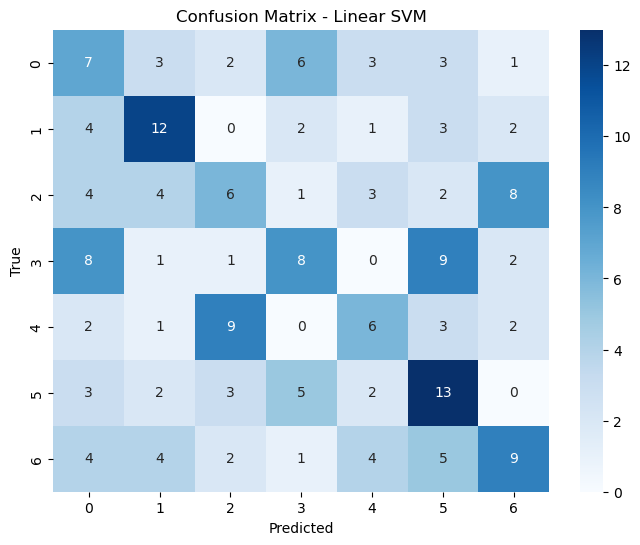

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Linear SVM")
plt.show()



Kernel: linear
Accuracy: 0.3279569892473118
              precision    recall  f1-score   support

           0       0.22      0.28      0.25        25
           1       0.44      0.50      0.47        24
           2       0.26      0.21      0.24        28
           3       0.35      0.28      0.31        29
           4       0.32      0.26      0.29        23
           5       0.34      0.46      0.39        28
           6       0.38      0.31      0.34        29

    accuracy                           0.33       186
   macro avg       0.33      0.33      0.33       186
weighted avg       0.33      0.33      0.32       186


Kernel: rbf
Accuracy: 0.43010752688172044
              precision    recall  f1-score   support

           0       0.14      0.08      0.10        25
           1       0.59      0.54      0.57        24
           2       0.33      0.32      0.33        28
           3       0.47      0.52      0.49        29
           4       0.36      0.22      0.27 

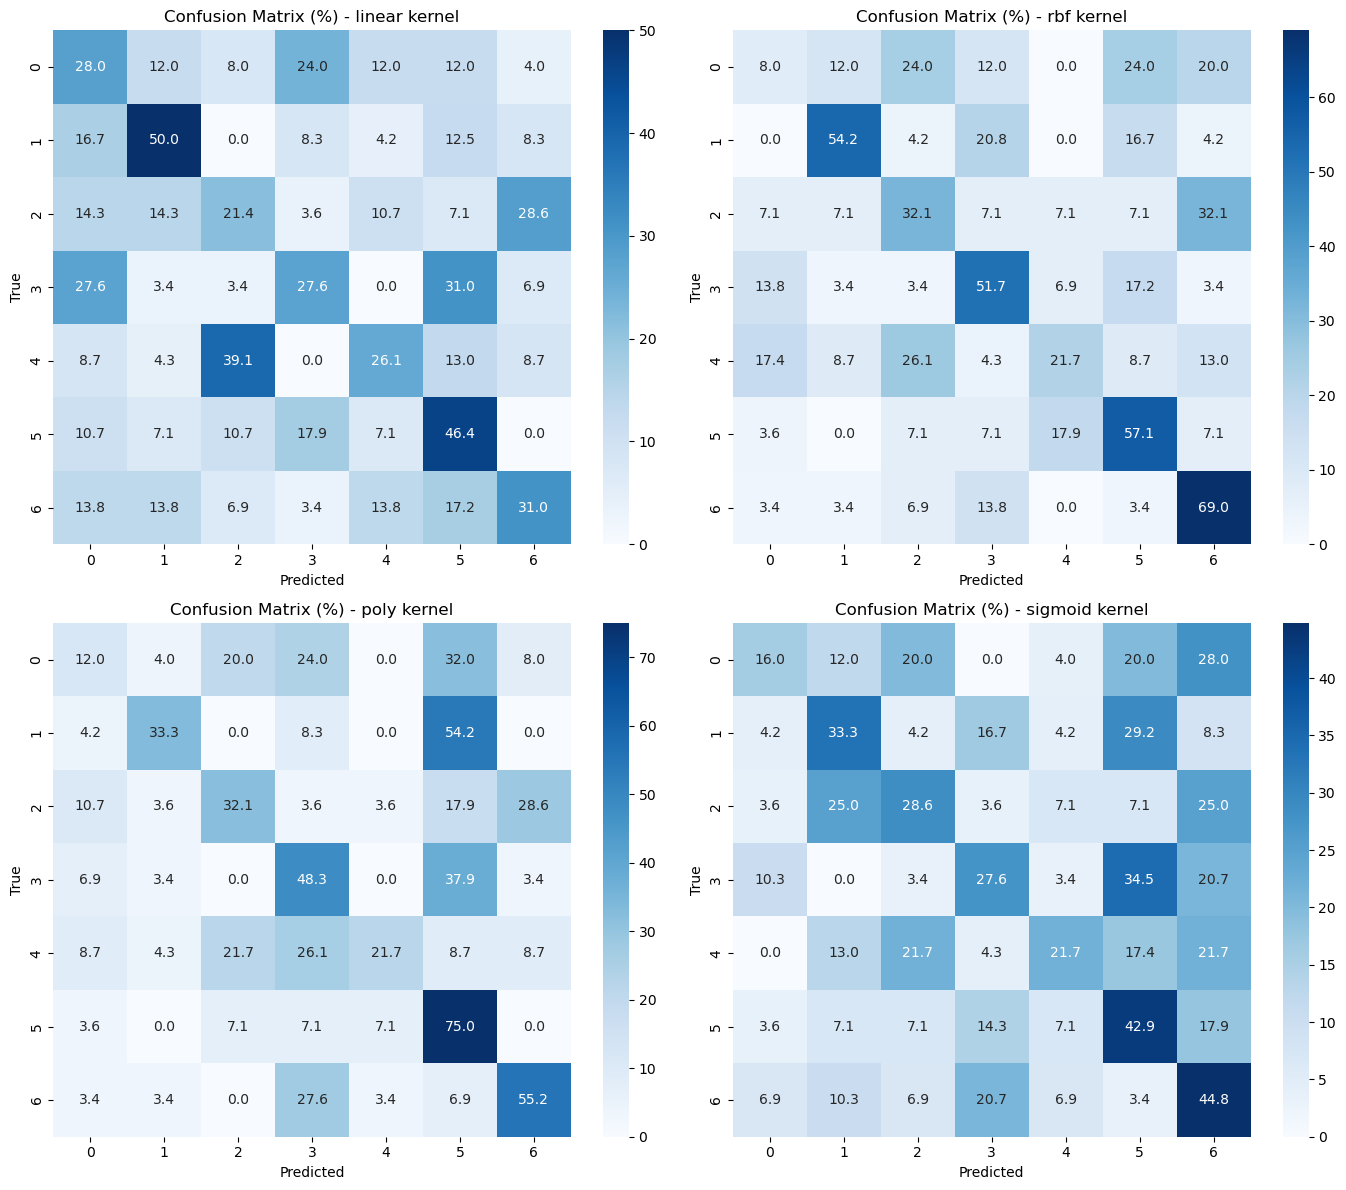

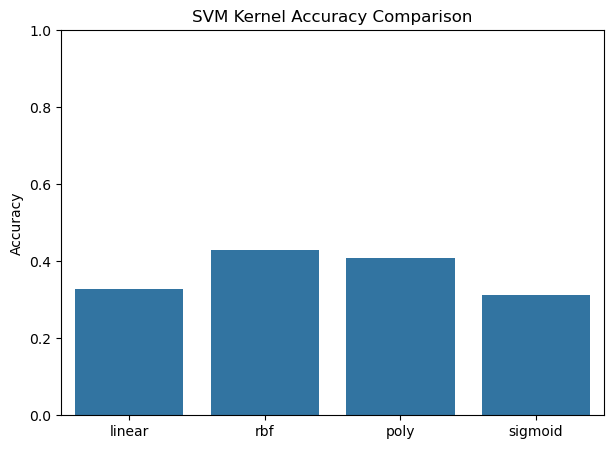

In [73]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

kernels = ["linear", "rbf", "poly", "sigmoid"]
results = {}
cms = {}

# Train and evaluate for each kernel
for k in kernels:
    svm = SVC(kernel=k, C=1.0, gamma="scale", random_state=42)
    svm.fit(X_train_top50, y_train)
    y_pred_k = svm.predict(X_test_top20)
    
    acc = accuracy_score(y_test, y_pred_k)
    results[k] = acc
    
    cm = confusion_matrix(y_test, y_pred_k, labels=np.unique(y))
    cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    cms[k] = cm_percent
    
    print(f"\nKernel: {k}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred_k))

# --- Plot confusion matrices (percent) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for i, k in enumerate(kernels):
    sns.heatmap(cms[k], annot=True, fmt=".1f", cmap="Blues",
                xticklabels=np.unique(y), yticklabels=np.unique(y), ax=axes[i])
    axes[i].set_title(f"Confusion Matrix (%) - {k} kernel")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

plt.tight_layout()
plt.show()

# --- Plot comparison of accuracies ---
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("SVM Kernel Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


## Grid search

In [74]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

# SVM with probability
svm = SVC(probability=True, random_state=42)

# Grid search
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,               # 5-fold cross-validation
    scoring="accuracy", # optimize accuracy
    n_jobs=-1,          # parallel
    verbose=2
)

grid.fit(X_train_top50, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Evaluate on test set
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test_top20)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.3s
[CV] END ......................C=0.1, gamma=0.01

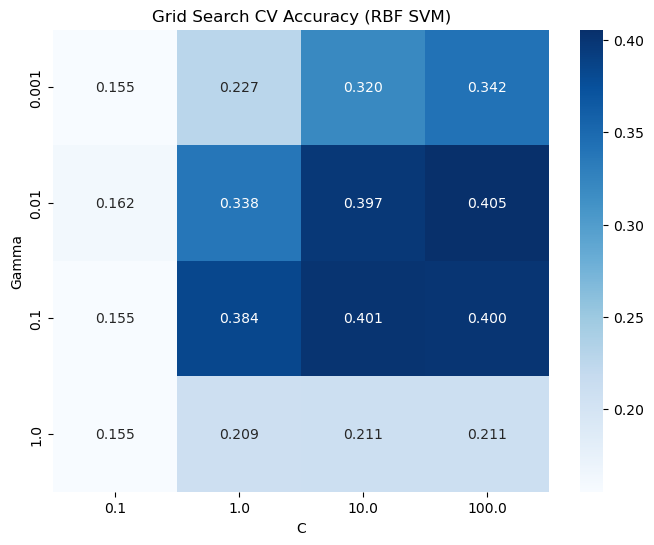

In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract results into DataFrame
results_df = pd.DataFrame(grid.cv_results_)

# Pivot to matrix form for heatmap
heatmap_data = results_df.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues")
plt.title("Grid Search CV Accuracy (RBF SVM)")
plt.ylabel("Gamma")
plt.xlabel("C")
plt.show()


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.2s
[CV] END ....................C=0.1, gamma=0.0001, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.2s[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.2s

[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.3s
[CV] END .....................C=0.1, gamma=0.00

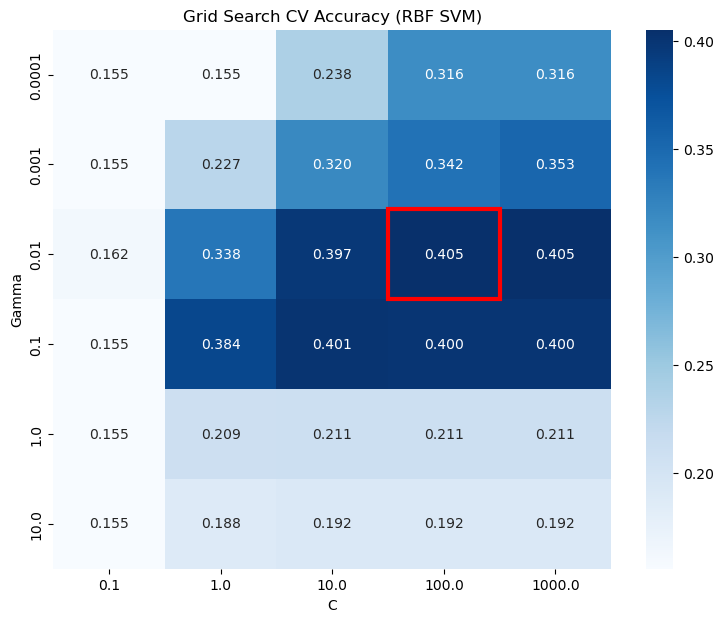

In [76]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Expanded parameter grid
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "kernel": ["rbf"]
}

# Grid search
svm = SVC(probability=True, random_state=42)
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)
grid.fit(X_train_top50, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Heatmap of results
results_df = pd.DataFrame(grid.cv_results_)
heatmap_data = results_df.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

plt.figure(figsize=(9,7))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues")

# Mark the best params
best_gamma = grid.best_params_["gamma"]
best_C = grid.best_params_["C"]
ax.add_patch(plt.Rectangle(
    (list(heatmap_data.columns).index(best_C), list(heatmap_data.index).index(best_gamma)),
    1, 1, fill=False, edgecolor="red", lw=3
))

plt.title("Grid Search CV Accuracy (RBF SVM)")
plt.ylabel("Gamma")
plt.xlabel("C")
plt.show()


Test accuracy: 0.45698924731182794

Classification Report:
               precision    recall  f1-score   support

           0       0.24      0.24      0.24        25
           1       0.42      0.58      0.49        24
           2       0.50      0.39      0.44        28
           3       0.39      0.38      0.39        29
           4       0.45      0.43      0.44        23
           5       0.64      0.57      0.60        28
           6       0.55      0.59      0.57        29

    accuracy                           0.46       186
   macro avg       0.46      0.46      0.45       186
weighted avg       0.46      0.46      0.46       186



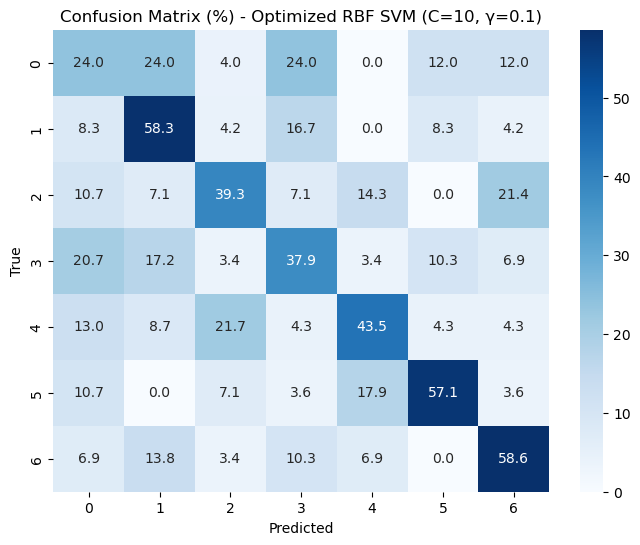

In [77]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Retrain with best params
best_svm = SVC(
    kernel="rbf",
    C=100,
    gamma=0.01,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_top50, y_train)

# Evaluate on test set
y_pred = best_svm.predict(X_test_top50)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix (percent)
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - Optimized RBF SVM (C=10, γ=0.1)")
plt.show()


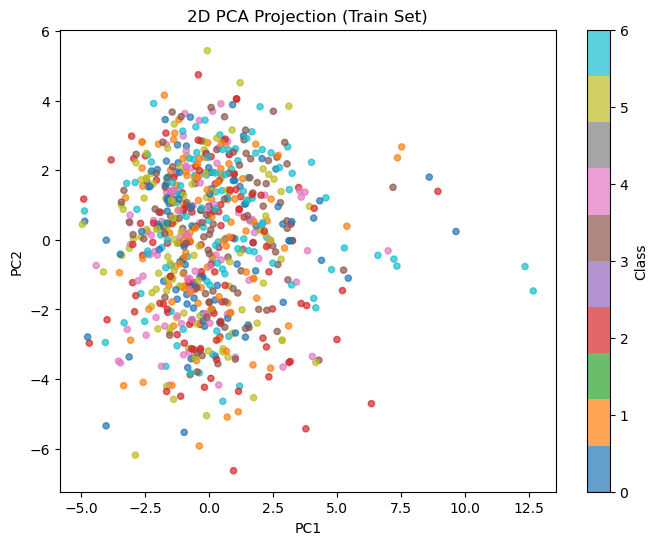

In [78]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import plotly.express as px

# ---------- PCA 2D ----------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_top50)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="tab10", alpha=0.7, s=20)  # smaller points
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (Train Set)")
plt.colorbar(label="Class")
plt.show()

# ---------- LDA 3D ----------
lda = LDA(n_components=3)
X_lda = lda.fit_transform(X_train_top50, y_train)

fig = px.scatter_3d(
    x=X_lda[:,0],
    y=X_lda[:,1],
    z=X_lda[:,2],
    color=y_train.astype(str),
    title="3D LDA Projection (Train Set)",
    labels={"color": "Class"},
    size_max=1  # shrink bubble size
)
fig.show()


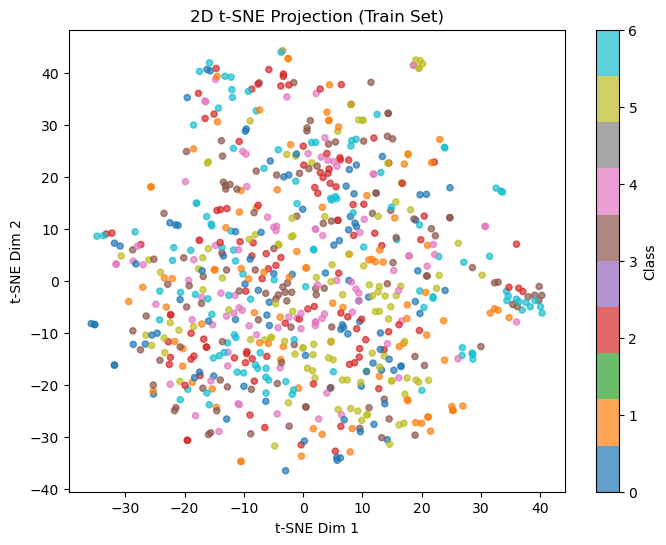

In [79]:
from sklearn.manifold import TSNE

# ---------- t-SNE 2D ----------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_train_top50)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train, cmap="tab10", alpha=0.7, s=20)
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.title("2D t-SNE Projection (Train Set)")
plt.colorbar(label="Class")
plt.show()


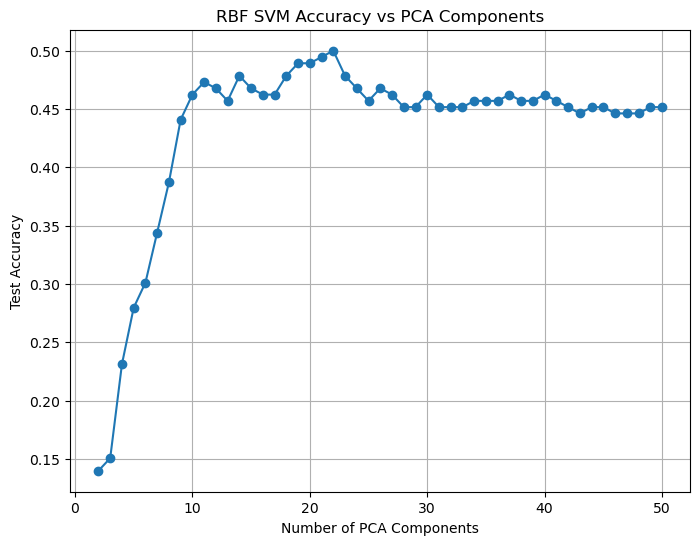

In [80]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
components = list(range(2, X_train_top50.shape[1]+1))  # from 2 up to 50

for n in components:
    # PCA reduction
    pca = PCA(n_components=n, random_state=42)
    X_train_pca = pca.fit_transform(X_train_top50)
    X_test_pca = pca.transform(X_test_top50)
    
    # RBF SVM with optimized params
    svm = SVC(
        kernel="rbf",
        C=10,
        gamma=0.1,
        probability=True,
        random_state=42
    )
    svm.fit(X_train_pca, y_train)
    y_pred = svm.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Plot results
plt.figure(figsize=(8,6))
plt.plot(components, accuracies, marker="o")
plt.xlabel("Number of PCA Components")
plt.ylabel("Test Accuracy")
plt.title("RBF SVM Accuracy vs PCA Components")
plt.grid(True)
plt.show()


Test accuracy: 0.478494623655914

Classification Report:
               precision    recall  f1-score   support

           0       0.36      0.32      0.34        25
           1       0.43      0.54      0.48        24
           2       0.43      0.46      0.45        28
           3       0.54      0.45      0.49        29
           4       0.38      0.43      0.41        23
           5       0.52      0.46      0.49        28
           6       0.66      0.66      0.66        29

    accuracy                           0.48       186
   macro avg       0.48      0.48      0.47       186
weighted avg       0.48      0.48      0.48       186



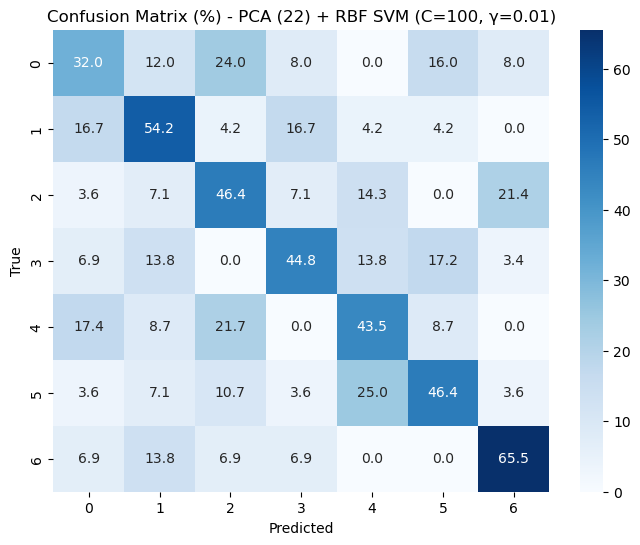

In [81]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- PCA (22 components) ---
pca = PCA(n_components=22, random_state=42)
X_train_pca = pca.fit_transform(X_train_top50)   # use top 50 features before PCA
X_test_pca = pca.transform(X_test_top50)

# --- Retrain with optimized RBF SVM ---
best_svm = SVC(
    kernel="rbf",
    C=100,
    gamma=0.01,
    probability=True,
    random_state=42
)
best_svm.fit(X_train_pca, y_train)

# --- Evaluate on test set ---
y_pred = best_svm.predict(X_test_pca)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Confusion matrix (percent) ---
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (%) - PCA (22) + RBF SVM (C=100, γ=0.01)")
plt.show()
